In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
model = ChatGroq(model= "llama-3.3-70b-versatile")

In [ ]:
# define schema
class LLMSchema(TypedDict):
    title : str
    outline : str
    content : str

In [4]:
def create_outline(state :LLMSchema) -> LLMSchema:
    title = state['title']
    prompt = f'generate a outline for a blog on the topic {title}'
    outline = model.invoke(prompt)
    state['outline'] = outline
    return state

In [6]:
def create_blog(state : LLMSchema) -> LLMSchema :
    title = state['title']
    outline = state['outline']
    prompt = f'write a detailed blog on {title} using a following outline\n {outline}'
    content = model.invoke(prompt)
    state['content'] = content
    return state

In [7]:
# create state
graph = StateGraph(LLMSchema)

# create node
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)


# create edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

# compile graph
workflow = graph.compile()

In [12]:
# execute the flow
initial_state = {"title":"rise of AI in China"}
final_state = workflow.invoke(initial_state)

In [11]:
print(final_state['outline'].content)

Here's a suggested outline for a blog on the rise of AI in China:

**Title:** "The Rise of AI in China: Opportunities, Challenges, and Implications"

**I. Introduction**

* Brief overview of the current state of AI development globally
* Importance of China in the global AI landscape
* Thesis statement: China is rapidly emerging as a leader in AI development, with significant implications for the country, the region, and the world.

**II. China's AI Ambitions**

* Overview of China's national AI strategy and goals
* Key initiatives and programs driving AI development in China, such as:
	+ Made in China 2025
	+ Next Generation Artificial Intelligence Development Plan
	+ China's Brain Project
* Discussion of China's investments in AI research and development

**III. Key Drivers of China's AI Rise**

* **Government Support**: Role of government policies, funding, and regulations in promoting AI development
* **Talent and Education**: China's growing pool of AI talent, education system, an

In [13]:
print(final_state['content'].content)

**The Rise of AI in China: A New Era of Technological Advancement**

**Introduction**

The world is witnessing a rapid growth in Artificial Intelligence (AI) technology, with significant implications for the global economy and society. Among the countries leading the charge in AI development and deployment is China. With its vast population, growing economy, and government support, China is emerging as a leader in the AI landscape. This blog will explore the rise of AI in China, its applications, innovations, challenges, and global implications.

**China's AI Strategy**

In 2017, the Chinese government unveiled its "New Generation Artificial Intelligence Development Plan," outlining the country's ambitions to become a global AI leader by 2030. The plan aims to develop AI technologies, including machine learning, natural language processing, and computer vision, to drive economic growth, improve healthcare, and enhance national security. To achieve these goals, the government has initia

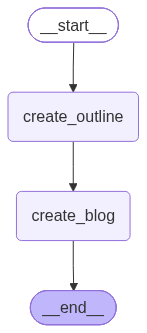

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())